Environment & Dependency Setup

In [2]:
import sys
!{sys.executable} -m pip install transformers torch tqdm pandas numpy optuna


Defaulting to user installation because normal site-packages is not writeable
  Using cached optuna-4.8.0-py3-none-any.whl.metadata (17 kB)
  Using cached alembic-1.18.4-py3-none-any.whl.metadata (7.2 kB)
  Using cached colorlog-6.10.1-py3-none-any.whl.metadata (11 kB)
  Using cached sqlalchemy-2.0.49-cp313-cp313-win_amd64.whl.metadata (9.8 kB)
  Using cached mako-1.3.11-py3-none-any.whl.metadata (2.9 kB)
  Using cached greenlet-3.4.0-cp313-cp313-win_amd64.whl.metadata (3.8 kB)
Using cached optuna-4.8.0-py3-none-any.whl (419 kB)
Using cached alembic-1.18.4-py3-none-any.whl (263 kB)
Using cached sqlalchemy-2.0.49-cp313-cp313-win_amd64.whl (2.1 MB)
Using cached greenlet-3.4.0-cp313-cp313-win_amd64.whl (238 kB)
Using cached colorlog-6.10.1-py3-none-any.whl (11 kB)
Using cached mako-1.3.11-py3-none-any.whl (78 kB)

   -------------------- ------------------- 3/6 [sqlalchemy]
   -------------------- ------------------- 3/6 [sqlalchemy]
   -------------------- ------------------- 3/6 [sqlalc


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: C:\Users\aramc\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Combine features from all models

In [13]:
import os
import json
import zipfile
import pandas as pd
import numpy as np
from tqdm import tqdm
import re

# ==========================================
# 1. SETUP & RELATIVE PATHS
# ==========================================
BASE_DIR = os.getcwd()  
AF3_DIR = os.path.join(BASE_DIR, "3seed_AF3")
BIPSPI_ROOT = os.path.join(BASE_DIR, "BIPSPI_outputs")
ROSETTA_FILE = os.path.join(BASE_DIR, "output_binding_energies.csv")
OUTPUT_FILE = os.path.join(BASE_DIR, "FeatureExtracted_DATA - Step 1.csv")

def get_pdb_code(text):
    if not isinstance(text, str): return None
    match = re.search(r'([0-9][A-Z0-9]{3})', text.upper())
    return match.group(1) if match else None

# ==========================================
# 2. PRE-LOAD EXTERNAL DATA (ROBUST MAPPING)
# ==========================================
print("📂 Indexing BIPSPI results...")
bipspi_db = {}
if os.path.exists(BIPSPI_ROOT):
    for root, dirs, files in os.walk(BIPSPI_ROOT):
        pdb = get_pdb_code(os.path.basename(root))
        if not pdb: continue
        for fn in files:
            if fn in ['PRED.res.tab.gz', 'PRED.res.tab']:
                try:
                    b_df = pd.read_table(os.path.join(root, fn), sep=r'\s+', 
                                        compression='gzip' if 'gz' in fn else None)
                    bipspi_db[pdb] = {
                        'L': b_df.groupby('resIdL')['prediction'].max().to_dict(),
                        'R': b_df.groupby('resIdR')['prediction'].max().to_dict()
                    }
                except: continue

print("📂 Indexing Rosetta Binding Energies...")
rosetta_map = {}
if os.path.exists(ROSETTA_FILE):
    rdf = pd.read_csv(ROSETTA_FILE)
    for _, row in rdf.iterrows():
        # FIX: Store by full filename (e.g. '2ido_a_b') AND PDB code ('2IDO')
        full_name = str(row.get('Proteins', '')).lower().replace('.cif', '').replace('.pdb', '')
        pdb = get_pdb_code(full_name)
        energy = row.get('del_G_B', np.nan)
        
        if full_name: rosetta_map[full_name] = energy
        if pdb and pdb not in rosetta_map: rosetta_map[pdb.lower()] = energy

# ==========================================
# 3. UPDATED HELPER (WITH SEED/MODEL TRACKING)
# ==========================================
def process_af3_data(pdb, folder, seed, model_idx, l_json, j_json, s_json, r_map, b_db):
    rows = []
    seq_list = []
    for entry in j_json[0]['sequences']:
        if 'proteinChain' in entry: seq_list.append(entry['proteinChain']['sequence'])
        elif 'rnaChain' in entry: seq_list.append(entry['rnaChain']['sequence'])

    t_chains = l_json['token_chain_ids']
    t_res = l_json['token_res_ids']
    plddt = l_json.get('token_plddt', l_json.get('atom_plddts', [np.nan]*len(t_chains)))
    pae = np.array(l_json.get('pae', []))
    contact = np.array(l_json.get('contact_probs', []))

    unique_cids = sorted(list(set(t_chains)))
    cid_to_idx = {cid: i for i, cid in enumerate(unique_cids)}

    # FIX: Robust Energy Lookup (Folder Name -> PDB Code -> NaN)
    complex_dg = r_map.get(folder.lower(), r_map.get(pdb.lower() if pdb else "", np.nan))

    b_score_map = {}
    if pdb in b_db:
        for side, chains in [('L', unique_cids[:-1]), ('R', [unique_cids[-1]])]:
            offset = 0
            for c in chains:
                c_len = len([tid for tid in t_chains if tid == c])
                for r_id in range(1, c_len + 1):
                    b_score_map[(c, r_id)] = b_db[pdb][side].get(offset + r_id - 1, 0)
                offset += c_len

    for i in range(len(t_chains)):
        c_val, r_id = t_chains[i], int(t_res[i])
        c_idx = cid_to_idx[c_val]
        try: aa = seq_list[c_idx][r_id - 1]
        except: aa = 'X'

        others = [j for j, val in enumerate(t_chains) if val != c_val]
        ipae_min = np.min(pae[i, others]) if others and pae.size > 0 else np.nan
        ipae_mean = np.mean(pae[i, others]) if others and pae.size > 0 else np.nan
        cp_max = np.max(contact[i, others]) if others and contact.size > 0 else 0

        rows.append({
            'complex_id': pdb,
            'folder_id': folder,         # To keep the original name
            'seed': seed,                # To distinguish seeds
            'model_idx': model_idx,      # To distinguish models 0-4
            'chain': chr(65 + c_idx),
            'residue': r_id,
            'amino_acid': aa,
            'af3_plddt': plddt[i],
            'af3_ipae_min': ipae_min,
            'af3_ipae_mean': ipae_mean,
            'af3_contact_prob_max': cp_max,
            'iptm': s_json.get('iptm', 0),
            'ptm': s_json.get('ptm', 0),
            'ranking_score': s_json.get('ranking_score', 0),
            'rosetta_dg': complex_dg,
            'bipspi_score': b_score_map.get((c_val, r_id), 0)
        })
    return rows

# ==========================================
# 4. MAIN DEEP-SCAN LOOP (EXACTLY YOUR LOGIC)
# ==========================================
print(f"📂 Deep-scanning {AF3_DIR}...")
all_rows = []

if not os.path.exists(AF3_DIR):
    print(f"❌ AF3 folder not found")
else:
    zip_files = [f for f in os.listdir(AF3_DIR) if f.endswith('.zip')]

    for z_fn in tqdm(zip_files, desc="Processing Zips"):
        z_path = os.path.join(AF3_DIR, z_fn)
        with zipfile.ZipFile(z_path, 'r') as z:
            files_by_dir = {}
            for name in z.namelist():
                parent = os.path.dirname(name)
                if parent not in files_by_dir: files_by_dir[parent] = []
                files_by_dir[parent].append(name)

            for folder, contents in files_by_dir.items():
                j_json_files = [c for c in contents if 'job_request.json' in c]
                if not j_json_files: continue
                
                full_data_files = [c for c in contents if 'full_data_' in c and c.endswith('.json')]
                
                for f_file in full_data_files:
                    try:
                        suffix = f_file.split('full_data_')[-1]
                        idx = suffix.split('.')[0]
                        s_file = next((c for c in contents if f'summary_confidences_{idx}.json' in c), None)
                        
                        if s_file:
                            # YOUR LOGIC: Folder name first, then Zip name
                            pdb = get_pdb_code(folder) or get_pdb_code(z_fn)
                            with z.open(f_file) as f: ld = json.load(f)
                            with z.open(j_json_files[0]) as f: jd = json.load(f)
                            with z.open(s_file) as f: sd = json.load(f)

                            all_rows.extend(process_af3_data(pdb, folder, z_fn, idx, ld, jd, sd, rosetta_map, bipspi_db))
                    except: continue

# ==========================================
# 5. EXPORT
# ==========================================
if all_rows:
    df = pd.DataFrame(all_rows)
    df.to_csv(OUTPUT_FILE, index=False)
    print(f"\n✅ INTEGRATION COMPLETE")
    print(f"📊 Processed {df['complex_id'].nunique()} complexes with seeds/models.")
else:
    print("❌ No valid data found.")

📂 Indexing BIPSPI results...
📂 Indexing Rosetta Binding Energies...
📂 Deep-scanning c:\Users\aramc\Desktop\PPI_Final_Pipeline\3seed_AF3...


Processing Zips: 100%|██████████| 7/7 [00:28<00:00,  4.13s/it]



✅ INTEGRATION COMPLETE
📊 Processed 103 complexes with seeds/models.


Generate ESM-2 Embeddings for all Complexes

In [1]:
import os
import torch
import pandas as pd
import numpy as np
from tqdm import tqdm
from transformers import AutoTokenizer, EsmModel
import warnings
import logging
import os

# 1. Hide standard Python warnings
warnings.filterwarnings("ignore")

# 2. Hide Hugging Face/Transformers loading warnings
from transformers import logging as transformers_logging
transformers_logging.set_verbosity_error()

# 3. Hide the Symlink warning specifically
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

# 4. (Optional) Disable the unauthenticated request warning
# Only do this if you aren't hitting rate limits
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "False"

# ==========================================
# 1. SETUP & LOADING
# ==========================================
BASE_DIR = os.getcwd() 
INPUT_FILE = os.path.join(BASE_DIR, "FeatureExtracted_DATA - Step 1.csv")
OUTPUT_CSV = os.path.join(BASE_DIR, "ESM_READY_DATA - Step 2.csv")
OUTPUT_NPY = os.path.join(BASE_DIR, "esm2_embeddings_650M - Step 2.npy")

model_name = "facebook/esm2_t33_650M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = EsmModel.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device).half() if torch.cuda.is_available() else model.to(device)
model.eval()

# ==========================================
# 2. PREPARE DATA (CRITICAL: SORTING)
# ==========================================
print("🧬 Loading and sorting data...")
df = pd.read_csv(INPUT_FILE)

# Sort by residue to ensure "".join() creates the correct biological sequence
df = df.sort_values(by=['complex_id', 'seed', 'model_idx', 'chain', 'residue'])

# Deduplicate to get unique sequences for embedding
df_unique = df.drop_duplicates(subset=['complex_id', 'chain', 'residue']).copy()

# Group by chain to build the sequence string
# We also keep track of which residue is at which string position
complex_groups = df_unique.groupby(['complex_id', 'chain'])
embedding_dict = {}

# ==========================================
# 3. GENERATION LOOP
# ==========================================
print(f"🧠 Generating Embeddings on {device}...")
with torch.no_grad():
    for (cid, chn), group in tqdm(complex_groups, total=len(complex_groups)):
        # Correctly join sorted residues into a sequence
        sequence = "".join(group['amino_acid'].astype(str))
        
        # Tokenize (ESM has a 1024 token limit; your data is fine at ~600 max)
        inputs = tokenizer(sequence, return_tensors="pt", padding=False, truncation=True, max_length=1024)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        outputs = model(**inputs)
        
        # Remove CLS/EOS tokens
        seq_embeddings = outputs.last_hidden_state[0, 1:-1, :].cpu().numpy().astype(np.float32)
        
        # KEY FIX: Map (complex, chain, residue_id) -> specific 1280-d vector
        # This handles gaps in numbering perfectly
        for i, res_id in enumerate(group['residue']):
            embedding_dict[(cid, chn, res_id)] = seq_embeddings[i]

# ==========================================
# 4. ALIGNMENT & EXPORT
# ==========================================
print("🔗 Mapping vectors back to full dataframe...")
# Use a list comprehension for 10x faster mapping than iterrows
final_list = [
    embedding_dict.get((r.complex_id, r.chain, r.residue)) 
    for r in df.itertuples()
]

# Filter out any rows that failed to map (should be 0)
valid_mask = [v is not None for v in final_list]
final_matrix = np.array([v for v in final_list if v is not None])

df_final = df[valid_mask].copy()
np.save(OUTPUT_NPY, final_matrix)
df_final.to_csv(OUTPUT_CSV, index=False)

print(f"\n✅ COMPLETE: Matrix shape {final_matrix.shape}")

C:\Users\aramc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 566/566 [00:00<00:00, 14882.56it/s]


🧬 Loading and sorting data...
🧠 Generating Embeddings on cpu...


100%|██████████| 223/223 [00:45<00:00,  4.88it/s]


🔗 Mapping vectors back to full dataframe...

✅ COMPLETE: Matrix shape (397475, 1280)


Combine Ground Truth with all Features

In [2]:
import os
import pandas as pd
import numpy as np
import string
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. SETUP & PATHS
# ==========================================
FEATURE_FILE = "ESM_READY_DATA - Step 2.csv"
TRUTH_FILE = "MASTER_GROUND_TRUTH.csv"
OUTPUT_FILE = "FINAL_TRAINING_DATA_WITH_LABELS - Step 3.csv"

# THE TRANSLATION MAP (Manual overrides for complex SARS targets)
CHAIN_MAPPING = {
    '7CZX': {'A': ['H', 'L'], 'B': ['B']},
    '7LS9': {'A': ['H', 'L'], 'B': ['A']},
    '7CZQ': {'A': ['H', 'L'], 'B': ['A']},
    '7D0D': {'A': ['H', 'L'], 'B': ['A']},
    '7DET': {'A': ['B', 'C'], 'B': ['A']},
    '7MSQ': {'A': ['H', 'L'], 'B': ['A']},
    '7X8P': {'A': ['B', 'C'], 'B': ['A']}
}

# ==========================================
# 2. LOAD & PREPARE
# ==========================================
print("📂 Loading data...")
df_feats = pd.read_csv(FEATURE_FILE)
df_truth = pd.read_csv(TRUTH_FILE)

df_feats['match_id'] = df_feats['complex_id'].str[:4].str.upper()
df_truth['pdb_id'] = df_truth['pdb_id'].astype(str).str.upper()

import string

print("🔄 Applying Advanced Dynamic Mapping (Handling Multi-Chains & Symmetry)...")

dynamic_mapping = {}

for folder in df_feats['folder_id'].dropna().unique():
    parts = str(folder).split('_')
    if len(parts) > 1:
        pdb = parts[0].upper()
        # 1. Decompose folder parts into a flat list of individual chains
        # e.g., '1hcf_ab_x' -> ['A', 'B', 'X']
        all_target_chains = []
        for p in parts[1:]:
            # Split 'ab' into ['A', 'B']
            all_target_chains.extend([char.upper() for char in p])
        
        # 2. Get unique AlphaFold chains present for this complex
        complex_af_chains = sorted(df_feats[df_feats['folder_id'] == folder]['chain'].unique())
        num_af = len(complex_af_chains)
        
        mapping = {}
        # 3. Cyclic/Group Mapping
        # If PDB has 4 chains (V,W,X,Y) and AF has 2 (A,B):
        # A gets [V, X], B gets [W, Y]
        for i, t_chain in enumerate(all_target_chains):
            af_chain = complex_af_chains[i % num_af]
            if af_chain not in mapping:
                mapping[af_chain] = []
            mapping[af_chain].append(t_chain)
        
        dynamic_mapping[pdb] = mapping

# Merge with manual overrides (SARS)
for pdb, mapping in dynamic_mapping.items():
    if pdb not in CHAIN_MAPPING:
        CHAIN_MAPPING[pdb] = mapping

print(f"✅ Created robust mapping for {len(dynamic_mapping)} complexes.")

# ==========================================
# 4. THE FLEXIBLE MERGE
# ==========================================
print("🔗 Aligning features to PDB truth...")

# Create a fast lookup dictionary for the truth data
# Key: (PDB_ID, Chain, Residue) -> Truth
truth_lookup = {}
for _, row in df_truth.iterrows():
    # Ensure chain and residue are treated correctly
    key = (str(row['pdb_id']), str(row['pdb_chain']), int(row['residue']))
    truth_lookup[key] = row['ground_truth']

all_labels = []

for i, row in tqdm(df_feats.iterrows(), total=len(df_feats)):
    pdb = row['match_id']
    f_chain = str(row['chain'])
    res = int(row['residue'])
    
    # Use mapping if available, otherwise assume 1:1 chain name match
    p_chains = CHAIN_MAPPING.get(pdb, {}).get(f_chain, [f_chain])
    
    # Check if this residue is an interface in ANY of the mapped chains
    is_interface = 0
    for p_chn in p_chains:
        if truth_lookup.get((pdb, p_chn, res)) == 1:
            is_interface = 1
            break
            
    all_labels.append(is_interface)

df_feats['ground_truth'] = all_labels

# ==========================================
# 5. FINAL VERIFICATION & SAVE
# ==========================================
df_final = df_feats.drop(columns=['match_id'])

print("\n" + "="*40)
print(f"✅ INTEGRATION COMPLETE")
print(f"📊 Total Training Samples: {len(df_final)}")
print(f"🎯 Interface Residues (Total): {df_final['ground_truth'].sum()}")

df_final.to_csv(OUTPUT_FILE, index=False)
print(f"💾 File saved: {OUTPUT_FILE}")
print("="*40)

📂 Loading data...
🔄 Applying Advanced Dynamic Mapping (Handling Multi-Chains & Symmetry)...
✅ Created robust mapping for 96 complexes.
🔗 Aligning features to PDB truth...


100%|██████████| 397475/397475 [00:04<00:00, 90938.57it/s]



✅ INTEGRATION COMPLETE
📊 Total Training Samples: 397475
🎯 Interface Residues (Total): 58665
💾 File saved: FINAL_TRAINING_DATA_WITH_LABELS - Step 3.csv


AlphaFold3 Baseline and Ensemble Model 

🧬 Reducing ESM-2 to 32 Dimensions...
🚀 Running Ablation Study...
   ⏳ Fold 1/5...
   ⏳ Fold 2/5...
   ⏳ Fold 3/5...
   ⏳ Fold 4/5...
   ⏳ Fold 5/5...


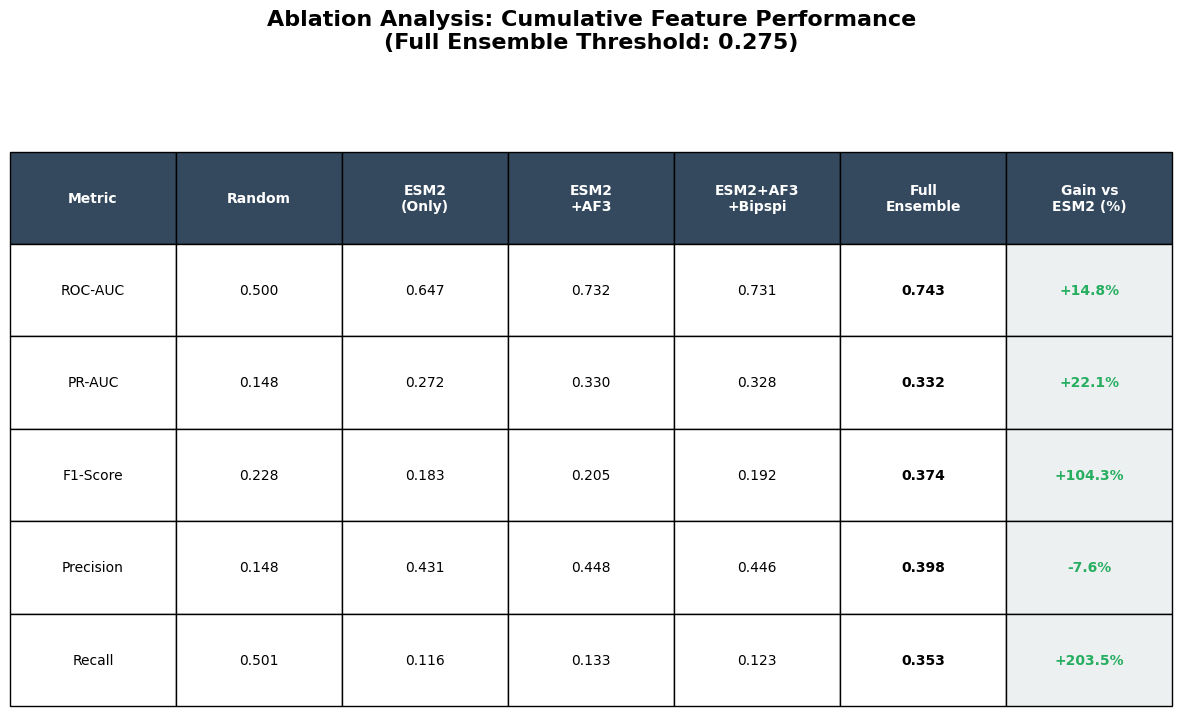

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (auc, roc_auc_score, precision_recall_curve, f1_score,
                             precision_score, recall_score)
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. DATA PREP
# ==========================================
CSV_PATH = "FINAL_TRAINING_DATA_WITH_LABELS - Step 3.csv"
NPY_PATH = "esm2_embeddings_650M - Step 2.npy"

df = pd.read_csv(CSV_PATH)
raw_esm = np.load(NPY_PATH, mmap_mode='r') 

# Define Feature Groups
af3_cols = ['af3_plddt', 'af3_ipae_min', 'af3_ipae_mean', 'af3_contact_prob_max', 'iptm', 'ptm', 'ranking_score']
bipspi_cols = ['bipspi_score']
rosetta_cols = ['rosetta_dg']

df[af3_cols + bipspi_cols + rosetta_cols] = df[af3_cols + bipspi_cols + rosetta_cols].fillna(0)
mask = df['ground_truth'].notnull().values
df_c = df[mask].reset_index(drop=True)
y = df_c['ground_truth'].astype(int).values
groups = df_c['complex_id'].values 

print("🧬 Reducing ESM-2 to 32 Dimensions...")
pca = PCA(n_components=32, random_state=42)
esm_pca = pca.fit_transform(raw_esm[mask]) 
del raw_esm; gc.collect()

# ==========================================
# 2. ABLATION CROSS-VALIDATION
# ==========================================
cv = GroupKFold(n_splits=5)

# Containers for each stage
oof_rand = np.random.uniform(0, 1, len(y))
oof_esm = np.zeros(len(y))
oof_esm_af3 = np.zeros(len(y))
oof_esm_af3_bip = np.zeros(len(y))
oof_full = np.zeros(len(y)) # ESM + AF3 + Bip + Rosetta

# Using Trial 24 params for the final stage
BEST_W = 0.2576
rf = RandomForestClassifier(n_estimators=172, max_depth=20, min_samples_leaf=10, class_weight='balanced', n_jobs=-1, random_state=42)
gbm = HistGradientBoostingClassifier(max_iter=139, learning_rate=0.01367, l2_regularization=3.436, random_state=42)

print("🚀 Running Ablation Study...")
train_thresholds = []

for fold, (train_idx, val_idx) in enumerate(cv.split(df_c, y, groups=groups)):
    print(f"   ⏳ Fold {fold+1}/5...")
    scaler = StandardScaler()
    
    # 1. ESM Alone
    X_tr, X_val = esm_pca[train_idx], esm_pca[val_idx]
    rf.fit(X_tr, y[train_idx]); oof_esm[val_idx] = rf.predict_proba(X_val)[:, 1]
    
    # 2. ESM + AF3
    X_tr = np.hstack([esm_pca[train_idx], scaler.fit_transform(df_c.loc[train_idx, af3_cols])])
    X_val = np.hstack([esm_pca[val_idx], scaler.transform(df_c.loc[val_idx, af3_cols])])
    rf.fit(X_tr, y[train_idx]); oof_esm_af3[val_idx] = rf.predict_proba(X_val)[:, 1]
    
    # 3. ESM + AF3 + Bipspi
    X_tr = np.hstack([X_tr, scaler.fit_transform(df_c.loc[train_idx, bipspi_cols])])
    X_val = np.hstack([X_val, scaler.transform(df_c.loc[val_idx, bipspi_cols])])
    rf.fit(X_tr, y[train_idx]); oof_esm_af3_bip[val_idx] = rf.predict_proba(X_val)[:, 1]
    
    # 4. FULL (ESM + AF3 + Bipspi + Rosetta)
    X_tr_final = np.hstack([X_tr, scaler.fit_transform(df_c.loc[train_idx, rosetta_cols])])
    X_val_final = np.hstack([X_val, scaler.transform(df_c.loc[val_idx, rosetta_cols])])
    
    rf.fit(X_tr_final, y[train_idx])
    gbm.fit(X_tr_final, y[train_idx])
    
    p_rf = rf.predict_proba(X_val_final)[:, 1]
    p_gbm = gbm.predict_proba(X_val_final)[:, 1]
    oof_full[val_idx] = (BEST_W * p_rf) + ((1 - BEST_W) * p_gbm)
    
    # Calibration
    p_tr = (BEST_W * rf.predict_proba(X_tr_final)[:, 1]) + ((1 - BEST_W) * gbm.predict_proba(X_tr_final)[:, 1])
    p, r, t = precision_recall_curve(y[train_idx], p_tr)
    f1_t = np.divide(2*p*r, p+r, out=np.zeros_like(p), where=(p+r)!=0)
    train_thresholds.append(t[np.argmax(f1_t[:-1])])

# ==========================================
# 3. FINAL TABLE DATA
# ==========================================
best_thresh = np.mean(train_thresholds)

def get_m(y_t, p_s, thresh=0.5):
    y_p = (p_s >= thresh).astype(int)
    pre, rec, _ = precision_recall_curve(y_t, p_s)
    return [roc_auc_score(y_t, p_s), auc(rec, pre), f1_score(y_t, y_p), precision_score(y_t, y_p), recall_score(y_t, y_p)]

m_rand = get_m(y, oof_rand, 0.5)
m_esm = get_m(y, oof_esm, 0.5)
m_esm_af3 = get_m(y, oof_esm_af3, 0.5)
m_esm_bip = get_m(y, oof_esm_af3_bip, 0.5)
m_full = get_m(y, oof_full, best_thresh)

metrics = ['ROC-AUC', 'PR-AUC', 'F1-Score', 'Precision', 'Recall']
table_rows = []

for i, m_name in enumerate(metrics):
    # Gain calculation using ESM2 name in logic
    gain = ((m_full[i] - m_esm[i]) / m_esm[i] * 100) if m_esm[i] > 0 else 0
    
    table_rows.append([
        m_name,
        f"{m_rand[i]:.3f}",
        f"{m_esm[i]:.3f}",
        f"{m_esm_af3[i]:.3f}",
        f"{m_esm_bip[i]:.3f}",
        f"{m_full[i]:.3f}",
        f"{gain:+.1f}%"
    ])

# ==========================================
# 4. PLOT TABLE
# ==========================================
fig, ax = plt.subplots(figsize=(15, 8))
ax.axis('off')

# Updated headers with ESM2 and Gain vs ESM2
headers = ["Metric", "Random", "ESM2\n(Only)", "ESM2\n+AF3", "ESM2+AF3\n+Bipspi", "Full\nEnsemble", "Gain vs\nESM2 (%)"]

tbl = ax.table(cellText=table_rows, colLabels=headers, loc='center', cellLoc='center', bbox=[0, 0, 1, 0.9])
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.0, 3.5)

# Styling: Header, Gain Column, and Bold Full Ensemble
for (r, c), cell in tbl.get_celld().items():
    # Style Header
    if r == 0:
        cell.set_facecolor('#34495e')
        cell.set_text_props(color='white', weight='bold')
    
    # Bold the "Full Ensemble" column (Index 5)
    if c == 5 and r > 0:
        cell.set_text_props(weight='bold')
        
    # Style the "Gain" column (Index 6)
    if c == 6 and r > 0:
        cell.set_facecolor('#ecf0f1')
        cell.set_text_props(weight='bold', color='#27ae60')

plt.title(f"Ablation Analysis: Cumulative Feature Performance\n(Full Ensemble Threshold: {best_thresh:.3f})", fontsize=16, weight='bold', pad=30)
plt.show()

🏆 Top 10 Best Predicted Complexes:
   complex_id    pr_auc
5        1CGI  0.935469
3        1AY7  0.911811
75       3P57  0.783636
60       2OOB  0.775230
14       1GRN  0.772118
41       1XD3  0.746507
1        1AK4  0.740794
79       4CPA  0.682209
40       1VFB  0.674062
54       2I25  0.669956

⚠️ Top 10 Worst Predicted Complexes:
   complex_id    pr_auc
44       1Z5Y  0.118331
47       2A9K  0.109851
69       3AAD  0.098296
29       1PVH  0.095315
72       3FN1  0.089373
9        1EFN  0.061148
68       3A4S  0.049529
45       1ZHI  0.034125
50       2C0L  0.017849
73       3H2V  0.013559


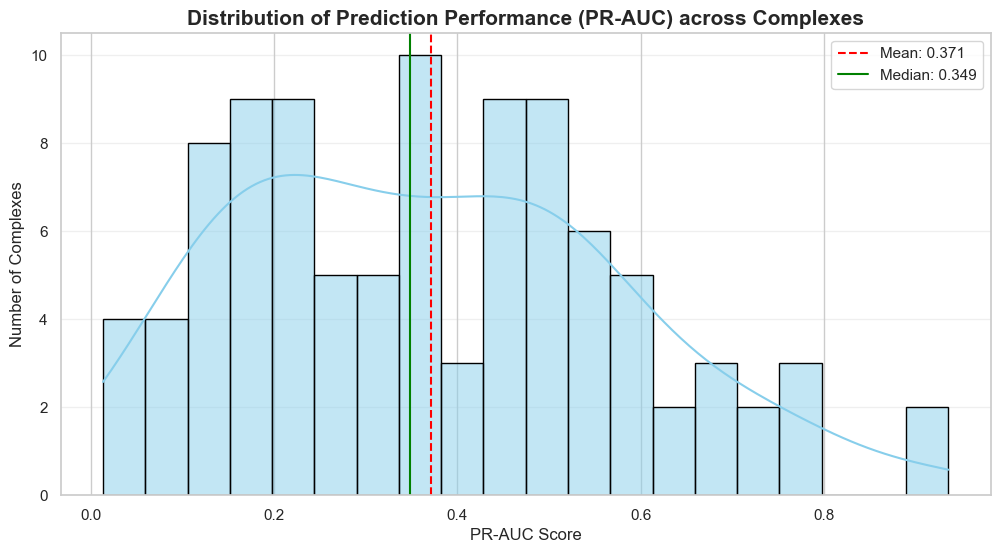

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import average_precision_score

# 1. Calculate PR-AUC per Complex
complex_results = []
unique_complexes = df_c['complex_id'].unique()

for cid in unique_complexes:
    mask_cid = df_c['complex_id'] == cid
    y_true = y[mask_cid]
    y_prob = oof_full[mask_cid]
    
    # Only calculate if there is at least one interface residue
    if sum(y_true) > 0:
        score = average_precision_score(y_true, y_prob)
        complex_results.append({'complex_id': cid, 'pr_auc': score})

res_df = pd.DataFrame(complex_results).sort_values(by='pr_auc', ascending=False)

# 2. Identify Top 10 Best and Worst
top_10 = res_df.head(10)
bottom_10 = res_df.tail(10)

print("🏆 Top 10 Best Predicted Complexes:")
print(top_10)
print("\n⚠️ Top 10 Worst Predicted Complexes:")
print(bottom_10)

# 3. Plotting the Distribution
plt.figure(figsize=(12, 6))

# Histogram + KDE
sns.histplot(res_df['pr_auc'], bins=20, kde=True, color='skyblue', edgecolor='black')

# Add lines for Average and Median
plt.axvline(res_df['pr_auc'].mean(), color='red', linestyle='--', label=f'Mean: {res_df["pr_auc"].mean():.3f}')
plt.axvline(res_df['pr_auc'].median(), color='green', linestyle='-', label=f'Median: {res_df["pr_auc"].median():.3f}')

plt.title('Distribution of Prediction Performance (PR-AUC) across Complexes', fontsize=15, weight='bold')
plt.xlabel('PR-AUC Score', fontsize=12)
plt.ylabel('Number of Complexes', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

Leave-One-Out Validation (7CZX)

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (auc, roc_auc_score, precision_recall_curve, f1_score,
                             accuracy_score, precision_score, recall_score)
import warnings

# Ignore unnecessary warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. SETUP & LOCAL PATHS
# ==========================================
TARGET_COMPLEX = "7CZX"  # Change this to "7D0D" or any other specific target!
BASE_DIR = os.getcwd() 

# Input files
CSV_PATH = os.path.join(BASE_DIR, "FINAL_TRAINING_DATA_WITH_LABELS - Step 3.csv")
NPY_PATH = os.path.join(BASE_DIR, "esm2_embeddings_650M - Step 2.npy")

print(f"📂 Loading data for Targeted Validation on {TARGET_COMPLEX}...")
df = pd.read_csv(CSV_PATH)
raw_esm = np.load(NPY_PATH)

# Feature Groups
af3_local = ['af3_plddt', 'af3_ipae_min', 'af3_ipae_mean', 'af3_contact_prob_max']
af3_global = ['iptm', 'ptm', 'ranking_score']
bio_feats = ['rosetta_dg', 'bipspi_score']
feature_cols = af3_local + af3_global + bio_feats

# ==========================================
# 2. PREPROCESSING & PCA
# ==========================================
# 1. Handle missing data
df[feature_cols] = df[feature_cols].fillna(0)

# 2. Filter for valid labels
mask = df['ground_truth'].notnull()
df_c = df[mask].copy()
esm_c = raw_esm[mask]

# 3. Normalize features
scaler = StandardScaler()
df_c[feature_cols] = scaler.fit_transform(df_c[feature_cols])

# 4. Dimension Reduction for ESM-2 (1280-D to 16-D for shallower models)
print(f"🧬 Reducing ESM-2 to 32 Dimensions...")
n_esm_comp = 32 # Set it here once
pca = PCA(n_components=n_esm_comp, random_state=42)
esm_pca = pca.fit_transform(esm_c)
# Dynamically create the exact number of labels needed
esm_labels = [f'ESM_PCA_{i+1}' for i in range(n_esm_comp)]

# Combine all features
X = np.hstack([df_c[feature_cols].values, esm_pca])
y = df_c['ground_truth'].astype(int).values
complex_ids = df_c['complex_id'].values
all_feat_names = feature_cols + esm_labels

# Split logic (Train on everything EXCEPT the target, test ONLY on the target)
train_mask = (complex_ids != TARGET_COMPLEX)
test_mask = (complex_ids == TARGET_COMPLEX)

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

# ==========================================
# 3. ENSEMBLE TRAINING (GOLDEN PARAMS)
# ==========================================
print(f"🚀 Training Golden Ensemble on {X_train.shape[0]} rows...")

# Random Forest: Updated with True Generalizing Params
rf = RandomForestClassifier(n_estimators=250, max_depth=10, class_weight='balanced', random_state=42)
# HistGBM: Updated with True Generalizing Params
gbm = HistGradientBoostingClassifier(max_iter=250, max_depth=5, l2_regularization=15.0, random_state=42)


rf.fit(X_train, y_train)
gbm.fit(X_train, y_train)

# Ensemble Prediction (30/70 Weighting - Favoring GBM)
prob_rf = rf.predict_proba(X_test)[:, 1]
prob_gbm = gbm.predict_proba(X_test)[:, 1]
ensemble_probs = (0.50 * prob_rf) + (0.50 * prob_gbm)

# ==========================================
# 4. METRIC OPTIMIZATION
# ==========================================
target_roc_auc = roc_auc_score(y_test, ensemble_probs)
p, r, t = precision_recall_curve(y_test, ensemble_probs)
pr_auc = auc(r, p)

# Find the threshold that maximizes the F1-Score on the test set
f1_array = np.divide(2*p*r, p+r, out=np.zeros_like(p), where=(p+r)!=0)
best_threshold = t[np.argmax(f1_array[:-1])]
y_pred = (ensemble_probs >= best_threshold).astype(int)

metrics_data = [
    ["Target ROC-AUC", f"{target_roc_auc:.4f}"],
    ["Target AUC-PR", f"{pr_auc:.4f}"],
    ["Overall Accuracy", f"{accuracy_score(y_test, y_pred)*100:.1f}%"],
    ["Interface Precision", f"{precision_score(y_test, y_pred)*100:.1f}%"],
    ["Interface Recall", f"{recall_score(y_test, y_pred)*100:.1f}%"],
    ["Interface F1-Score", f"{f1_score(y_test, y_pred)*100:.1f}%"]
]

# ==========================================
# 5. VISUALIZATION
# ==========================================
print("📊 Generating Visualizations...")
sns.set_theme(style="whitegrid")

# Chart 1: Metrics Table
fig, ax = plt.subplots(figsize=(7, 5))
ax.axis('off')
table = ax.table(cellText=metrics_data, colLabels=["Metric", "Value"], loc='center', cellLoc='left', colWidths=[0.5, 0.25])
table.auto_set_font_size(False); table.set_fontsize(11); table.scale(1.1, 3.5)
for (row, col), cell in table.get_celld().items():
    if row == 0: cell.set_facecolor('#2c3e50'); cell.set_text_props(color='white', weight='bold')
plt.savefig(f'Performance_{TARGET_COMPLEX}.png', dpi=300, bbox_inches='tight')

# Chart 2: Top 20 Predictors
importances = rf.feature_importances_
fi_df = pd.DataFrame({'Feature': all_feat_names, 'Importance': importances})
plt.figure(figsize=(10, 8))
top_20_fi = fi_df.sort_values('Importance', ascending=False).head(20)
sns.barplot(x='Importance', y='Feature', data=top_20_fi, palette='viridis')
plt.title(f'Top 20 Predictors (Golden Params) for {TARGET_COMPLEX}')
plt.savefig(f'Importance_Individual_{TARGET_COMPLEX}.png', dpi=300, bbox_inches='tight')

# Chart 3: Categorical Importance
category_map = {
    'AF3 Metrics': af3_local + af3_global,
    'ESM-2 (PCA Reduced)': esm_labels,
    'PyRosetta (Energy)': ['rosetta_dg'],
    'BIPSPI (Bioinfo)': ['bipspi_score']
}
cat_data = []
for cat, feats in category_map.items():
    imp = fi_df[fi_df['Feature'].isin(feats)]['Importance'].sum()
    cat_data.append({'Category': cat, 'Total Importance': imp})

plt.figure(figsize=(10, 5))
sns.barplot(x='Total Importance', y='Category', data=pd.DataFrame(cat_data).sort_values('Total Importance', ascending=False), palette='magma')
plt.title(f'Importance by Feature Type ({TARGET_COMPLEX})')
plt.savefig(f'Importance_Category_{TARGET_COMPLEX}.png', dpi=300, bbox_inches='tight')

plt.show()

print("\n" + "="*40)
print(f"✅ VALIDATION COMPLETE ON {TARGET_COMPLEX}")
print(f"📈 ROC-AUC: {target_roc_auc:.4f}")
print(f"🎯 PR-AUC Score: {pr_auc:.4f}")
print("="*40)

📂 Loading data for Targeted Validation on 7CZX...
🧬 Reducing ESM-2 to 32 Dimensions...
🚀 Training Golden Ensemble on 395275 rows...


Leave-One-Out Validation (7D0D)

📂 Loading data for Targeted Validation on 7D0D...
🧬 Reducing ESM-2 to 16 Dimensions...
🚀 Training Golden Ensemble on 395285 rows...
📊 Generating Visualizations...


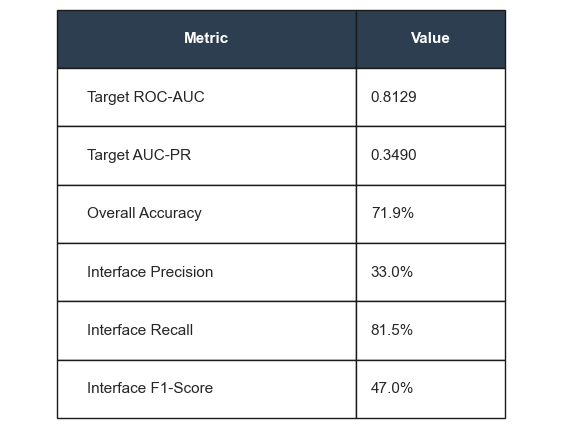

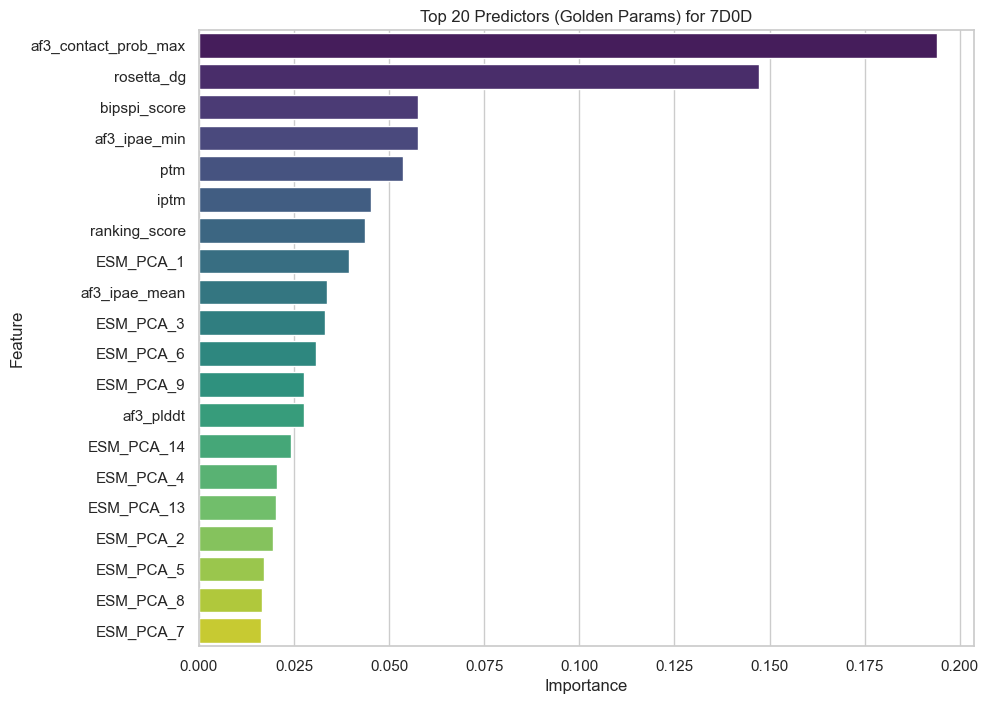

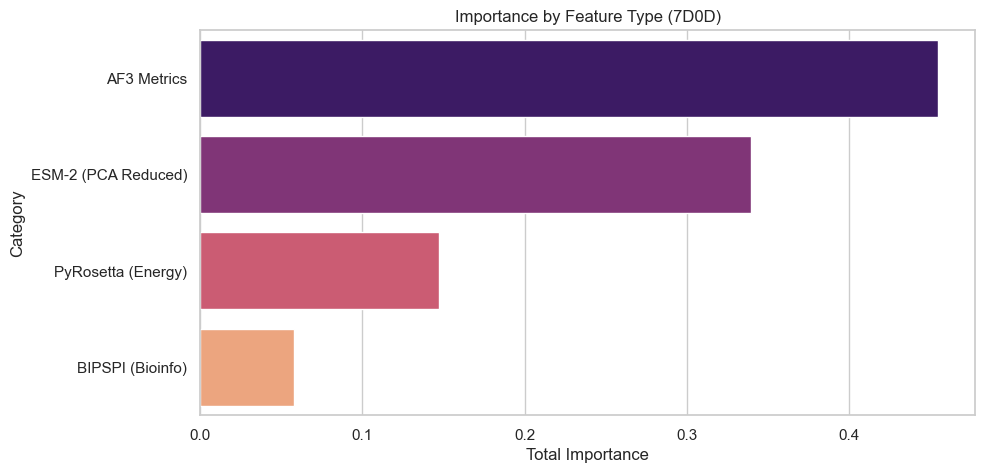


✅ VALIDATION COMPLETE ON 7D0D
📈 ROC-AUC: 0.8129
🎯 PR-AUC Score: 0.3490


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (auc, roc_auc_score, precision_recall_curve, f1_score,
                             accuracy_score, precision_score, recall_score)
import warnings

# Ignore unnecessary warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. SETUP & LOCAL PATHS
# ==========================================
TARGET_COMPLEX = "7D0D"  
BASE_DIR = os.getcwd() 

# Input files
CSV_PATH = os.path.join(BASE_DIR, "FINAL_TRAINING_DATA_WITH_LABELS - Step 3.csv")
NPY_PATH = os.path.join(BASE_DIR, "esm2_embeddings_650M - Step 2.npy")

print(f"📂 Loading data for Targeted Validation on {TARGET_COMPLEX}...")
df = pd.read_csv(CSV_PATH)
raw_esm = np.load(NPY_PATH)

# Feature Groups
af3_local = ['af3_plddt', 'af3_ipae_min', 'af3_ipae_mean', 'af3_contact_prob_max']
af3_global = ['iptm', 'ptm', 'ranking_score']
bio_feats = ['rosetta_dg', 'bipspi_score']
feature_cols = af3_local + af3_global + bio_feats

# ==========================================
# 2. PREPROCESSING & PCA
# ==========================================
# 1. Handle missing data
df[feature_cols] = df[feature_cols].fillna(0)

# 2. Filter for valid labels
mask = df['ground_truth'].notnull()
df_c = df[mask].copy()
esm_c = raw_esm[mask]

# 3. Normalize features
scaler = StandardScaler()
df_c[feature_cols] = scaler.fit_transform(df_c[feature_cols])

# 4. Dimension Reduction for ESM-2 (1280-D to 32-D for shallower models)
print(f"🧬 Reducing ESM-2 to 32 Dimensions...")
n_esm_comp = 32 # Set it here once
pca = PCA(n_components=n_esm_comp, random_state=42)
esm_pca = pca.fit_transform(esm_c)
# Dynamically create the exact number of labels needed
esm_labels = [f'ESM_PCA_{i+1}' for i in range(n_esm_comp)]

# Combine all features
X = np.hstack([df_c[feature_cols].values, esm_pca])
y = df_c['ground_truth'].astype(int).values
complex_ids = df_c['complex_id'].values
all_feat_names = feature_cols + esm_labels

# Split logic (Train on everything EXCEPT the target, test ONLY on the target)
train_mask = (complex_ids != TARGET_COMPLEX)
test_mask = (complex_ids == TARGET_COMPLEX)

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

# ==========================================
# 3. ENSEMBLE TRAINING (GOLDEN PARAMS)
# ==========================================
print(f"🚀 Training Golden Ensemble on {X_train.shape[0]} rows...")

# Random Forest: Updated with True Generalizing Params
rf = RandomForestClassifier(n_estimators=250, max_depth=10, class_weight='balanced', random_state=42)
# HistGBM: Updated with True Generalizing Params
gbm = HistGradientBoostingClassifier(max_iter=250, max_depth=5, l2_regularization=15.0, random_state=42)


rf.fit(X_train, y_train)
gbm.fit(X_train, y_train)

# Ensemble Prediction (30/70 Weighting - Favoring GBM)
prob_rf = rf.predict_proba(X_test)[:, 1]
prob_gbm = gbm.predict_proba(X_test)[:, 1]
ensemble_probs = (0.50 * prob_rf) + (0.50 * prob_gbm)

# ==========================================
# 4. METRIC OPTIMIZATION
# ==========================================
target_roc_auc = roc_auc_score(y_test, ensemble_probs)
p, r, t = precision_recall_curve(y_test, ensemble_probs)
pr_auc = auc(r, p)

# Find the threshold that maximizes the F1-Score on the test set
f1_array = np.divide(2*p*r, p+r, out=np.zeros_like(p), where=(p+r)!=0)
best_threshold = t[np.argmax(f1_array[:-1])]
y_pred = (ensemble_probs >= best_threshold).astype(int)

metrics_data = [
    ["Target ROC-AUC", f"{target_roc_auc:.4f}"],
    ["Target AUC-PR", f"{pr_auc:.4f}"],
    ["Overall Accuracy", f"{accuracy_score(y_test, y_pred)*100:.1f}%"],
    ["Interface Precision", f"{precision_score(y_test, y_pred)*100:.1f}%"],
    ["Interface Recall", f"{recall_score(y_test, y_pred)*100:.1f}%"],
    ["Interface F1-Score", f"{f1_score(y_test, y_pred)*100:.1f}%"]
]

# ==========================================
# 5. VISUALIZATION
# ==========================================
print("📊 Generating Visualizations...")
sns.set_theme(style="whitegrid")

# Chart 1: Metrics Table
fig, ax = plt.subplots(figsize=(7, 5))
ax.axis('off')
table = ax.table(cellText=metrics_data, colLabels=["Metric", "Value"], loc='center', cellLoc='left', colWidths=[0.5, 0.25])
table.auto_set_font_size(False); table.set_fontsize(11); table.scale(1.1, 3.5)
for (row, col), cell in table.get_celld().items():
    if row == 0: cell.set_facecolor('#2c3e50'); cell.set_text_props(color='white', weight='bold')
plt.savefig(f'Performance_{TARGET_COMPLEX}.png', dpi=300, bbox_inches='tight')

# Chart 2: Top 20 Predictors
importances = rf.feature_importances_
fi_df = pd.DataFrame({'Feature': all_feat_names, 'Importance': importances})
plt.figure(figsize=(10, 8))
top_20_fi = fi_df.sort_values('Importance', ascending=False).head(20)
sns.barplot(x='Importance', y='Feature', data=top_20_fi, palette='viridis')
plt.title(f'Top 20 Predictors (Golden Params) for {TARGET_COMPLEX}')
plt.savefig(f'Importance_Individual_{TARGET_COMPLEX}.png', dpi=300, bbox_inches='tight')

# Chart 3: Categorical Importance
category_map = {
    'AF3 Metrics': af3_local + af3_global,
    'ESM-2 (PCA Reduced)': esm_labels,
    'PyRosetta (Energy)': ['rosetta_dg'],
    'BIPSPI (Bioinfo)': ['bipspi_score']
}
cat_data = []
for cat, feats in category_map.items():
    imp = fi_df[fi_df['Feature'].isin(feats)]['Importance'].sum()
    cat_data.append({'Category': cat, 'Total Importance': imp})

plt.figure(figsize=(10, 5))
sns.barplot(x='Total Importance', y='Category', data=pd.DataFrame(cat_data).sort_values('Total Importance', ascending=False), palette='magma')
plt.title(f'Importance by Feature Type ({TARGET_COMPLEX})')
plt.savefig(f'Importance_Category_{TARGET_COMPLEX}.png', dpi=300, bbox_inches='tight')

plt.show()

print("\n" + "="*40)
print(f"✅ VALIDATION COMPLETE ON {TARGET_COMPLEX}")
print(f"📈 ROC-AUC: {target_roc_auc:.4f}")
print(f"🎯 PR-AUC Score: {pr_auc:.4f}")
print("="*40)